## Preparations

In [1]:
from typing import Dict, Any, Optional
from collections import defaultdict
from tqdm.autonotebook import tqdm

import torch
import torch.nn.functional as F
from torch.optim import Optimizer, Adagrad

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap


torch.manual_seed(12345)

<ipython-input-1-4008a1628ad6>:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
plt.style.use("ggplot")
color = plt.rcParams["axes.prop_cycle"].by_key()
cd = {
    "red": "#E24A33",
    "gray": "#777777",
    "blue": "#348ABD",
    "green": "#8EBA42"
}
colors = [cd["red"], cd["blue"], cd["gray"], cd["green"]]

cmap_long_short = ListedColormap(LinearSegmentedColormap.from_list("long_short", [cd["green"], cd["red"]])(torch.linspace(0, 1, 6))).colors
cmap_epsilon_greedy = ListedColormap(LinearSegmentedColormap.from_list("epsilon_greedy", [cd["green"], cd["blue"]])(torch.linspace(0, 1, 6))).colors

## Settings

In [3]:
n_user_groups = 20
n_content_groups = 20

In [4]:
# affine params
alpha_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 0.5), torch.full((n_user_groups, ), 0.1)), min=0)
beta_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 5.), torch.full((n_user_groups, ), 1.)), min=0)

alpha_contents = torch.clip(torch.normal(torch.full((n_content_groups, ), 0.5), torch.full((n_content_groups, ), 0.1)), min=0)
beta_contents = torch.clip(torch.normal(torch.full((n_user_groups, ), 5.), torch.full((n_user_groups, ), 1.)), min=0)

In [5]:
# concave params
max_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 200.), torch.full((n_user_groups, ), 50.)), min=0.)
tau_users = torch.clip(torch.normal(torch.full((n_user_groups, ), 4.), torch.full((n_user_groups, ), 1.)), min=1.)

max_contents = torch.clip(torch.normal(torch.full((n_content_groups, ), 200.), torch.full((n_content_groups, ), 50.)), min=0.)
tau_contents = torch.clip(torch.normal(torch.full((n_content_groups, ), 40.), torch.full((n_content_groups, ), 10.)), min=1.)

In [6]:
# base preference
dim_emb = 20
user_features = torch.bernoulli(torch.full((n_user_groups, dim_emb), 0.5))
content_features = torch.bernoulli(torch.full((n_content_groups, dim_emb), 0.5))
base_reward_matrix = user_features @ content_features.T

In [7]:
# population effect
gamma_populations = torch.clip(torch.normal(torch.ones((n_content_groups, dim_emb)), torch.full((n_content_groups, dim_emb), 0.3)), min=0)
const_populations = torch.zeros((n_content_groups, dim_emb))

max_populations = torch.clip(torch.normal(torch.full((n_content_groups, dim_emb), 5.), torch.full((n_content_groups, dim_emb), 1.)), min=0.)
tau_populations = torch.clip(torch.normal(torch.full((n_content_groups, dim_emb), 40.), torch.full((n_content_groups, dim_emb), 10.)), min=1.)

In [8]:
# other paramas
initial_user_population = torch.clip(torch.normal(torch.full((n_user_groups, ), 50.), torch.full((n_user_groups, ), 10.)), min=10.)
initial_content_population = torch.clip(torch.normal(torch.full((n_content_groups, ), 50.), torch.full((n_content_groups, ), 10.)), min=10.)
user_reactiveness = torch.clip(torch.normal(torch.full((n_user_groups, ), 0.1), torch.full((n_user_groups, ), 0.03)), min=0., max=1.)
content_reactiveness = torch.clip(torch.normal(torch.full((n_content_groups, ), 0.1), torch.full((n_user_groups, ), 0.03)), min=0., max=1.)

In [9]:
def sigmoid(z: torch.Tensor):
    return 1 / (1 + torch.exp(- z))

In [10]:
def concave_dynamics(
    z: torch.Tensor,        # (input_dim, ) or (input_dim_1, input_dim_2)
    tau: torch.Tensor,      # (input_dim, ) or (input_dim_1, input_dim_2)
    max_val: torch.Tensor,  # (input_dim, ) or (input_dim_1, input_dim_2)
):
    return max_val * (sigmoid(z / tau) - 0.5)

In [11]:
def affine_dynamics(
    z: torch.Tensor,      # (input_dim, ) or (input_dim_1, input_dim_2)
    alpha: torch.Tensor,  # (input_dim, ) or (input_dim_1, input_dim_2)
    beta: torch.Tensor,   # (input_dim, ) or (input_dim_1, input_dim_2)
):
    return alpha * z + beta

## Interaction functions

In [12]:
# f_l
def population_effect(
    content_population: torch.Tensor,  # (n_content_groups, )
    setting: str = "affine",           # "affine" or "concave"
):
    content_population = torch.tile(content_population, (dim_emb, 1))

    if setting == "affine":
        population_effect_coef = affine_dynamics(content_population, alpha=gamma_populations, beta=const_populations)
    elif setting == "concave":
        population_effect_coef = concave_dynamics(content_population, tau=tau_populations, max_val=max_populations)
    else:
        raise NotImplementedError()

    population_effect = user_features @ population_effect_coef.T

    return population_effect

In [13]:
# \bar{\lambda}_u
def reference_population_user(
    utility: torch.Tensor,    # (n_user_groups, )
    setting: str = "affine",  # "affine" or "concave"
):
    if setting == "affine":
        reference = affine_dynamics(utility, alpha=alpha_users, beta=beta_users)
    elif setting == "concave":
        reference = concave_dynamics(utility, tau=tau_users, max_val=max_users)
    else:
        raise NotImplementedError()

    return reference

In [14]:
# \bar{\lambda}_l
def reference_population_content(
    exposure: torch.Tensor,   # (n_content_groups, )
    setting: str = "affine",  # "affine" or "concave"
):
    if setting == "affine":
        reference = affine_dynamics(exposure, alpha=alpha_contents, beta=beta_contents)
    elif setting == "concave":
        reference = concave_dynamics(exposure, tau=tau_contents, max_val=max_contents)
    else:
        raise NotImplementedError()

    return reference

In [15]:
# q = b + f(\lambda_l)
def utility_matrix_fn(
    content_population: torch.Tensor,   # (n_content_groups, )
    setting: str = "affine",            # "affine" or "concave"
):
    content_population_effect = population_effect(content_population, setting=setting)
    utility_matrix = base_reward_matrix + content_population_effect
    return utility_matrix

In [16]:
# q_l
def user_utility_fn(policy: torch.Tensor, utility_matrix: torch.Tensor):
    user_utility = (policy * utility_matrix).sum(dim=1)
    return user_utility

In [17]:
# e_l
def content_exposure_fn(policy: torch.Tensor, user_population: torch.Tensor):
    content_exposure = (policy * torch.tile(user_population, (n_content_groups, 1)).T).sum(dim=0)
    return content_exposure

In [18]:
# \lambda
def population_dynamics(
    user_population: torch.Tensor,     # (n_user_groups, )
    content_population: torch.Tensor,  # (n_content_groups, )
    user_utility: torch.Tensor,        # (n_user_groups, )
    content_exposure: torch.Tensor,    # (n_content_groups, )
    setting: str = "affine",           # "affine" or "concave"
):
    user_population = (1 - user_reactiveness) * user_population + user_reactiveness * reference_population_user(user_utility, setting=setting)
    content_population = (1 - content_reactiveness) * content_population + content_reactiveness * reference_population_content(content_exposure, setting=setting)
    return user_population, content_population

## Policies

In [19]:
def softmax(
    z: torch.Tensor,  # (n_dim1, n_dim_2)
    tau: float = 0.01,
):
    z = z - z.max(dim=1, keepdim=True)[0]
    return F.softmax(z, dim=1)

In [20]:
def long_term_policy(
    utility_matrix: torch.Tensor,                   # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,                  # (n_user_groups, )
    content_population: torch.Tensor,               # (n_content_groups, )
    initial_policy: Optional[torch.Tensor] = None,  # (n_user_groups, n_content_groups)
    setting: str = "affine",                        # "affine" or "concave"
    optimizer: Optimizer = Adagrad,
    max_grad_steps: int = 100,
    lr: float = 1e-2,
    **kwargs,
):
    policy_logit = torch.tensor(torch.log(initial_policy + 1e-4), requires_grad=True)
    optimizer = optimizer([policy_logit], lr=lr)

    for i in range(max_grad_steps):
        prev_policy_logit = policy_logit.clone().detach()
        prev_policy = softmax(policy_logit).clone().detach()

        # immediate outcome
        policy = softmax(policy_logit)
        user_utility = user_utility_fn(policy, utility_matrix)
        content_exposure = content_exposure_fn(policy, content_population)

        # reference point
        user_reference = reference_population_user(user_utility, setting=setting)
        content_reference = reference_population_content(content_exposure, setting=setting)
        reference_utility_matrix = utility_matrix_fn(content_reference, setting=setting)

        # one_step_optimal_policy
        with torch.no_grad():
            one_step_optimal_policy = softmax(reference_utility_matrix)

        # total welfare at reference
        user_utility = (one_step_optimal_policy * reference_utility_matrix).sum(dim=1)
        total_welfare = (user_reference * user_utility).sum()

        normalizer = user_population.sum()
        loss = - total_welfare / normalizer

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return policy.detach()

In [21]:
def epsilon_greedy_policy(
    utility_matrix: torch.Tensor,  # (n_user_groups, n_content_groups)
    epsilon: float = 0.0,
    **kwargs,
):
    n_user_groups, n_content_groups = utility_matrix.shape

    greedy_idx = utility_matrix.max(dim=1)[1]

    prob = torch.full((n_user_groups, n_content_groups), epsilon / n_content_groups)
    prob[torch.arange(n_user_groups), greedy_idx] += 1 - epsilon
    return prob

In [22]:
def long_short_tradeoff_policy(
    utility_matrix: torch.Tensor,    # (n_user_groups, n_content_groups)
    long_term_policy: torch.Tensor,  # (n_user_groups, n_content_groups)
    beta: float = 0.0,
    **kwargs,
):
    n_user_groups, n_content_groups = utility_matrix.shape

    greedy_idx = utility_matrix.max(dim=1)[1]
    short_term_policy = torch.zeros((n_user_groups, n_content_groups))
    short_term_policy[torch.arange(n_user_groups), greedy_idx] = 1

    prob = (1 - beta) * short_term_policy + beta * long_term_policy
    return prob

In [23]:
def policy_fn(
    initial_policy: torch.Tensor,      # (n_user_groups, n_content_groups)
    utility_matrix: torch.Tensor,      # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,     # (n_user_groups, )
    content_population: torch.Tensor,  # (n_content_groups, )
    policy_type: str,                  # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,         # in [0, 1]
    setting: str = "affine",           # "affine" or "concave"
):
    n_grad_steps = 1000 if initial_policy is None else 100

    if initial_policy is None:
        initial_policy = epsilon_greedy_policy(
            utility_matrix=utility_matrix,
            epsilon=0.2,
        )

    if policy_type == "long_short_tradeoff":
        if policy_param == 0.0:
            long_term = epsilon_greedy_policy(
                utility_matrix=utility_matrix,
                epsilon=0.,
            )
        else:
            long_term = long_term_policy(
                initial_policy=initial_policy,
                utility_matrix=utility_matrix,
                user_population=user_population,
                content_population=content_population,
                n_grad_steps=n_grad_steps,
                setting=setting,
            )

        balanced = long_short_tradeoff_policy(
            utility_matrix=utility_matrix,
            long_term_policy=long_term,
            beta=policy_param,
        )

    elif policy_type == "epsilon_greedy":
        balanced = epsilon_greedy_policy(
            utility_matrix=utility_matrix,
            epsilon=policy_param,
        )

    else:
        raise NotImplementedError()

    return balanced

## Experiments

In [24]:
def statistics(
    prev_policy: torch.Tensor,            # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,        # (n_user_groups, )
    content_population: torch.Tensor,     # (n_content_groups, )
    setting: str = "affine",              # "affine" or "concave"
    policy_type: str = "epsilon_greedy",  # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,            # in [0, 1]
):
    utility_matrix = utility_matrix_fn(content_population, setting=setting)
    policy_matrix = policy_fn(prev_policy, utility_matrix, user_population, content_population, policy_type=policy_type, policy_param=policy_param, setting=setting)
    user_utility = user_utility_fn(policy_matrix, utility_matrix)
    content_exposure = content_exposure_fn(policy_matrix, user_population)
    total_welfare = (user_utility * user_population).sum()
    return utility_matrix, policy_matrix, user_utility, content_exposure, total_welfare

In [25]:
def step(
    prev_policy: torch.Tensor,            # (n_user_groups, n_content_groups)
    user_population: torch.Tensor,        # (n_user_groups, )
    content_population: torch.Tensor,     # (n_content_groups, )
    setting: str = "affine",              # "affine" or "concave"
    policy_type: str = "epsilon_greedy",  # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,            # in [0, 1]
):
    utility_matrix, policy_matrix, user_utility, content_exposure, total_welfare = statistics(prev_policy, user_population, content_population, setting=setting, policy_type=policy_type, policy_param=policy_param)
    user_population, content_population = population_dynamics(user_population, content_population, user_utility, content_exposure, setting=setting)
    return user_population, content_population, utility_matrix, policy_matrix, user_utility, content_exposure, total_welfare

In [26]:
def rollout(
    initial_user_population: torch.Tensor,     # (n_user_groups, )
    initial_content_population: torch.Tensor,  # (n_content_groups, )
    setting: str = "affine",                   # "affine" or "concave"
    policy_type: str = "epsilon_greedy",       # "long_short_tradeoff" or "epsilon_greedy"
    policy_param: float = 0.0,                 # in [0, 1]
    n_steps: int = 1000,                       # > 1
):
    user_population_logs = torch.zeros((n_steps + 1, n_user_groups))
    content_population_logs = torch.zeros((n_steps + 1, n_content_groups))
    utility_matrix_logs = torch.zeros((n_steps + 1, n_user_groups, n_content_groups))
    policy_matrix_logs = torch.zeros((n_steps + 1, n_user_groups, n_content_groups))
    user_utility_logs = torch.zeros((n_steps + 1, n_user_groups))
    content_exposure_logs = torch.zeros((n_steps + 1, n_content_groups))
    total_welfare_logs = torch.zeros((n_steps + 1, ))

    user_population_logs[0] = initial_user_population
    content_population_logs[0] = initial_content_population

    user_population = initial_user_population
    content_population = initial_content_population

    policy_matrix = None

    with tqdm(torch.arange(n_steps)) as pbar:
        for t, ch in enumerate(pbar):
            pbar.set_description(f"[rollout simulation (param={policy_param:.1f}): t={t}]")
            pbar.set_postfix(
                {
                    "user_population": f"{user_population_logs[t].sum():.4g}",
                    "content_population": f"{content_population_logs[t].sum():.4g}",
                    "total_welfare": f"{total_welfare_logs[t - 1]:.4g}",
                }
            )

            # if not converged, continue simulation
            if not (
                (torch.abs(user_population_logs[t].sum() - user_population_logs[t - 1].sum()) < 0.01) and
                (torch.abs(content_population_logs[t].sum() - content_population_logs[t - 1].sum()) < 0.01) and
                (torch.abs(total_welfare_logs[t - 1].sum() - total_welfare_logs[t - 2].sum()) < 0.01)
            ):
                (
                    user_population,
                    content_population,
                    utility_matrix,
                    policy_matrix,
                    user_utility,
                    content_exposure,
                    total_welfare,
                ) = step(policy_matrix, user_population, content_population, setting=setting, policy_type=policy_type, policy_param=policy_param)

            user_population_logs[t + 1] = user_population
            content_population_logs[t + 1] = content_population
            utility_matrix_logs[t] = utility_matrix
            policy_matrix_logs[t] = policy_matrix
            user_utility_logs[t] = user_utility
            content_exposure_logs[t] = content_exposure
            total_welfare_logs[t] = total_welfare

    (
        utility_matrix,
        policy_matrix,
        user_utility,
        content_exposure,
        total_welfare,
    ) = statistics(policy_matrix, user_population, content_population, setting=setting, policy_type=policy_type, policy_param=policy_param)

    utility_matrix_logs[-1] = utility_matrix
    policy_matrix_logs[-1] = policy_matrix
    user_utility_logs[-1] = user_utility
    content_exposure_logs[-1] = content_exposure
    total_welfare_logs[-1] = total_welfare

    return user_population_logs, content_population_logs, utility_matrix_logs, policy_matrix_logs, user_utility_logs, content_exposure_logs, total_welfare_logs

In [27]:
def calc_regret(logs: Dict[str, Any], myopic_logs: Dict[str, Any], long_term_logs: Dict[str, Any], optimal_logs: Dict[str, Any]):
    user_population = logs["user_population"]
    utility_matrix = logs["utility_matrix"]
    n_steps = len(user_population)

    policy_welfare = logs["total_welfare"]
    optimal_welfare = optimal_logs["total_welfare"]

    one_step_optimal_utility = utility_matrix.max(dim=2)[0]
    one_step_optimal_walfare = (user_population * one_step_optimal_utility).sum(dim=1)

    long_term_user_population = long_term_logs["user_population"]
    long_term_utility_matrix = long_term_logs["utility_matrix"]

    long_term_utility = long_term_utility_matrix.max(dim=2)[0]
    long_term_walfare = (long_term_user_population * long_term_utility).sum(dim=1)

    myopic_regret = one_step_optimal_walfare - policy_welfare
    long_term_regret = long_term_walfare - one_step_optimal_walfare
    total_regret = optimal_welfare - policy_welfare

    return myopic_regret, long_term_regret, total_regret

## Visualization functions

In [28]:
def visualization_of_dynamics_with_varying_params(
    logs: Dict[str, Any],
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
    setting: str = "affine",  # "affine" or "concave"
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    n_params = len(params)
    n_steps = len(logs[0]["total_welfare"])
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"
    colors = cmap_epsilon_greedy if policy_type == "epsilon_greedy" else cmap_long_short

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2.8))
    for i, param in enumerate(params):
        axes[0].plot(torch.arange(n_steps)[::log_interval], logs[i]["total_welfare"][::log_interval], label=f"{param_name}={param:.1f}", marker=".", color=colors[i])
        axes[1].plot(torch.arange(n_steps)[::log_interval], logs[i]["user_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i])
        axes[2].plot(torch.arange(n_steps)[::log_interval], logs[i]["content_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i])

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        axes[i].set_xlabel("time steps")

    axes[0].set_ylabel("total welfare")
    axes[1].set_ylabel("total population")
    axes[2].set_ylabel("total population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend(loc="lower right")

    plt.tight_layout()

    plt.savefig(f"{setting}_increase_dynamics_{policy_type}.png", dpi=300, bbox_inches="tight")


In [29]:
def visualization_of_dynamics_with_representative_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    setting: str = "affine",  # "affine" or "concave"
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    n_steps = len(long_short_logs[0]["total_welfare"])
    colors = {
        "myopic": cmap_long_short[0],
        "long-term": cmap_long_short[-1],
        "uniform": cmap_epsilon_greedy[-1],
    }

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2.8))
    axes[0].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["total_welfare"][::log_interval], label="myopic", marker=".", color=colors["myopic"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["user_population"][::log_interval].sum(dim=1), label="myopic", marker=".", color=colors["myopic"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], long_short_logs[0]["content_population"][::log_interval].sum(dim=1), label="myopic", marker=".", color=colors["myopic"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["total_welfare"][::log_interval], label="long-term", marker=".", color=colors["long-term"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["user_population"][::log_interval].sum(dim=1), label="long-term", marker=".", color=colors["long-term"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], long_short_logs[5]["content_population"][::log_interval].sum(dim=1), label="long-term", marker=".", color=colors["long-term"])

    axes[0].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["total_welfare"][::log_interval], label="uniform", marker=".", color=colors["uniform"])
    axes[1].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["user_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors["uniform"])
    axes[2].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["content_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors["uniform"])

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        axes[i].set_xlabel("time steps")

    axes[0].set_ylabel("total welfare")
    axes[1].set_ylabel("total population")
    axes[2].set_ylabel("total population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend(fontsize=11)

    plt.tight_layout()

    plt.savefig(f"{setting}_increase_dynamics_representative.png", dpi=300, bbox_inches="tight")


In [30]:
def visualization_of_utility_matrix_with_varying_params(
    logs: Dict[str, Any],
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
    setting: str = "affine",  # "affine" or "concave"
):
    n_params = len(params) + 1

    utility_matrix_dfs = dict()
    user_idxes = torch.tile(torch.arange(n_user_groups), (n_content_groups, 1)).T.flatten()
    content_idxes = torch.tile(torch.arange(n_content_groups), (n_user_groups, 1)).flatten()

    # initial population
    df = pd.DataFrame()
    df["value"] = logs[0]["utility_matrix"][0].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["initial"] = df

    for i, param in enumerate(params):
        df = pd.DataFrame()
        df["value"] = logs[i]["utility_matrix"][-1].flatten()
        df["viewer"] = user_idxes
        df["provider"] = content_idxes
        utility_matrix_dfs[i] = df

    fig, axes = plt.subplots(1, n_params, figsize=(5.2 * n_params, 4))
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"

    for i, param in enumerate(params):
        sns.heatmap(utility_matrix_dfs[i].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[i + 1], vmin=5.0, vmax=25.0, cmap="PiYG")
        axes[i + 1].set_title(f"final utility of {param_name}={param:.1f}")

    sns.heatmap(utility_matrix_dfs["initial"].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[0], vmin=5.0, vmax=25.0, cmap="PiYG")
    axes[0].set_title("initial utility")

    plt.savefig(f"{setting}_increase_reward_matrix_{policy_type}.png", dpi=300, bbox_inches="tight")


In [31]:
def visualization_of_utility_matrix_with_representitive_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    setting: str = "affine",  # "affine" or "concave"
):
    utility_matrix_dfs = dict()
    user_idxes = torch.tile(torch.arange(n_user_groups), (n_content_groups, 1)).T.flatten()
    content_idxes = torch.tile(torch.arange(n_content_groups), (n_user_groups, 1)).flatten()

    # initial population
    df = pd.DataFrame()
    df["value"] = long_short_logs[0]["utility_matrix"][0].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["initial"] = df

    # mypic
    df = pd.DataFrame()
    df["value"] = long_short_logs[0]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["myopic"] = df

    # long-term
    df = pd.DataFrame()
    df["value"] = long_short_logs[len(long_short_logs) - 1]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["long-term"] = df

    # uniform
    df = pd.DataFrame()
    df["value"] = epsilon_greedy_logs[len(epsilon_greedy_logs) - 1]["utility_matrix"][-1].flatten()
    df["viewer"] = user_idxes
    df["provider"] = content_idxes
    utility_matrix_dfs["uniform"] = df

    fig, axes = plt.subplots(1, 4, figsize=(5.2 * 4, 4))
    compared_methods = ["initial", "myopic", "long-term", "uniform"]
    # compared_methods = ["initial", "myopic", "long-term", "uniform", "best-long-short-balanced", "best-epsilon-greedy"]
    for i, method in enumerate(compared_methods):
        sns.heatmap(utility_matrix_dfs[method].pivot(index="viewer", columns="provider", values="value"), annot=False, ax=axes[i], vmin=5.0, vmax=25.0, cmap="PiYG")

        if i == 0:
            axes[0].set_title("initial utility")
        else:
            axes[i].set_title(f"final utility of {method}")

    plt.savefig(f"{setting}_increase_reward_matrix_representitive.png", dpi=300, bbox_inches="tight")


In [32]:
def visualization_of_regret_with_varying_params(
    logs: Dict[str, Any],
    best_param_id: int,
    long_term_param_id: int,
    policy_type: str,         # "long_short_tradeoff" or "epsilon_greedy"
    params: torch.Tensor,     # (n_params, )
    setting: str = "affine",  # "affine" or "concave"
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    fig, axes = plt.subplots(1, 4, figsize=(5 * 4, 2.8))
    param_name = "ε" if policy_type == "epsilon_greedy" else "β"
    colors = cmap_epsilon_greedy if policy_type == "epsilon_greedy" else cmap_long_short

    for i, param in enumerate(params):
        (
            myopic_regret,
            long_term_regret,
            total_regret,
        ) = calc_regret(logs[i], myopic_logs=logs[0], long_term_logs=logs[long_term_param_id], optimal_logs=logs[best_param_id])

        axes[0].plot(torch.cumsum(total_regret, dim=0), label=f"{param_name}={param:.1f}", color=colors[i])
        axes[1].plot(total_regret, label=f"{param_name}={param:.1f}", color=colors[i])
        axes[2].plot(long_term_regret, label=f"{param_name}={param:.1f}", color=colors[i])
        axes[3].plot(myopic_regret, label=f"{param_name}={param:.1f}", color=colors[i])

    axes[0].set_title("cumulative total regret")
    axes[1].set_title("total regret")
    axes[2].set_title("population regret")
    axes[3].set_title("policy regret")

    for i in range(4):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

        axes[i].set_xlabel("time steps")
        axes[i].set_ylabel("regret")

    axes[-1].legend(loc="upper right")

    plt.tight_layout()

    plt.savefig(f"{setting}_increase_regret_{policy_type}.png", dpi=300, bbox_inches="tight")


In [33]:
def visualization_of_regret_with_representative_methods(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    best_long_short_param_id: int,
    best_epsilon_greedy_param_id: int,
    setting: str = "affine",  # "affine" or "concave"
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    fig, axes = plt.subplots(1, 4, figsize=(5 * 4, 2.8))
    colors = {
        "myopic": cmap_long_short[0],
        "long-term": cmap_long_short[len(long_short_logs) - 1],
        "uniform": cmap_epsilon_greedy[len(epsilon_greedy_logs) - 1],
    }

    # myopic
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(long_short_logs[0], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="myopic", color=colors["myopic"])
    axes[1].plot(total_regret, label="myopic", color=colors["myopic"])
    axes[2].plot(long_term_regret, label="myopic", color=colors["myopic"])
    axes[3].plot(myopic_regret, label="myopic", color=colors["myopic"])

    # long-term
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(long_short_logs[len(long_short_logs) - 1], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="long-term", color=colors["long-term"])
    axes[1].plot(total_regret, label="long-term", color=colors["long-term"])
    axes[2].plot(long_term_regret, label="long-term", color=colors["long-term"])
    axes[3].plot(myopic_regret, label="long-term", color=colors["long-term"])

    # uniform
    (
        myopic_regret,
        long_term_regret,
        total_regret,
    ) = calc_regret(epsilon_greedy_logs[len(epsilon_greedy_logs) - 1], myopic_logs=long_short_logs[0], long_term_logs=long_short_logs[len(long_short_logs) - 1], optimal_logs=long_short_logs[best_long_short_param_id])

    axes[0].plot(torch.cumsum(total_regret, dim=0), label="uniform", color=colors["uniform"])
    axes[1].plot(total_regret, label="uniform", color=colors["uniform"])
    axes[2].plot(long_term_regret, label="uniform", color=colors["uniform"])
    axes[3].plot(myopic_regret, label="uniform", color=colors["uniform"])

    # fig configs
    axes[0].set_title("cumulative total regret")
    axes[1].set_title("total regret")
    axes[2].set_title("population regret")
    axes[3].set_title("policy regret")

    for i in range(4):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

        axes[i].set_xlabel("time steps")
        axes[i].set_ylabel("regret")

    axes[-1].legend(fontsize=11)

    plt.tight_layout()

    plt.savefig(f"{setting}_increase_regret_representative.png", dpi=300, bbox_inches="tight")


In [34]:
def visualization_of_dynamics_main_text(
    long_short_logs: Dict[str, Any],
    epsilon_greedy_logs: Dict[str, Any],
    params: torch.Tensor,     # (n_params, )
    setting: str = "affine",  # "affine" or "concave"
    log_interval: int = 10,
    use_log_scale_for_xaxis: bool = False,
    use_log_scale_for_yaxis: bool = False,
):
    logs = long_short_logs

    n_params = len(params)
    n_steps = len(logs[0]["total_welfare"])
    param_name = "β"
    colors = cmap_long_short

    colors_ = {
        "uniform": cmap_epsilon_greedy[-1],
    }

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2.8))
    for i, param in enumerate(params):
        axes[0].plot(torch.arange(n_steps)[::log_interval], logs[i]["total_welfare"][::log_interval], label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)
        axes[1].plot(torch.arange(n_steps)[::log_interval], logs[i]["user_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)
        axes[2].plot(torch.arange(n_steps)[::log_interval], logs[i]["content_population"][::log_interval].sum(dim=1), label=f"{param_name}={param:.1f}", marker=".", color=colors[i], zorder=2)

    axes[0].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["total_welfare"][::log_interval], label="uniform", marker=".", color=colors_["uniform"], zorder=1)
    axes[1].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["user_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors_["uniform"], zorder=1)
    axes[2].plot(torch.arange(n_steps)[::log_interval], epsilon_greedy_logs[5]["content_population"][::log_interval].sum(dim=1), label="uniform", marker=".", color=colors_["uniform"], zorder=1)

    axes[0].set_title("total welfare")
    axes[1].set_title("total viewer population")
    axes[2].set_title("total provider population")

    for i in range(3):
        axes[i].set_xlabel("time steps")

    axes[0].set_ylabel("total welfare")
    axes[1].set_ylabel("total population")
    axes[2].set_ylabel("total population")

    for i in range(3):
        if use_log_scale_for_xaxis:
            axes[i].set_xscale("log")
        if use_log_scale_for_yaxis:
            axes[i].set_yscale("log")

    axes[-1].legend(loc="lower right")

    plt.tight_layout()

    plt.savefig(f"{setting}_increase_dynamics_main.png", dpi=300, bbox_inches="tight")


In [35]:
def visualization_of_population_effect(
    setting: str = "affine",  # "affine" or "concave"
    n_bins: int = 20,
):
    content_population = torch.logspace(1, 3, n_bins)
    reward = torch.zeros((n_bins, n_user_groups, n_content_groups))

    for i, val_ in enumerate(content_population):
        content_population_ = torch.full((n_content_groups, ), val_)
        content_population_effect_ = population_effect(content_population_, setting=setting)
        reward[i] = base_reward_matrix + content_population_effect_

    fig, axes = plt.subplots(1, 3, figsize=(5 * 3, 2))

    for i in range(3):  # 3 users
        for j in range(5):  # 5 contents
            axes[i].plot(content_population, reward[:, i, j], label=f"content {j + 1}")

        axes[i].set_title(f"population effect for viewer {i + 1}")
        axes[i].set_xlabel("viewer population")
        axes[i].set_ylabel("utility")
        axes[i].set_xscale("log")

    axes[-1].legend(loc="lower right")

    plt.savefig(f"{setting}_increase_population_effect.png", dpi=300, bbox_inches="tight")


## Main

In [36]:
def main(
    params: torch.Tensor,                 # (n_params, )
    setting: str = "affine",              # "affine" or "concave"
    policy_type: str = "epsilon_greedy",  # "long_short_tradeoff" or "epsilon_greedy"
    n_steps: int = 100,
):
    logs = defaultdict(dict)
    for i, param in enumerate(params):
        (
            user_population_logs,
            content_population_logs,
            utility_matrix_logs,
            policy_matrix_logs,
            user_utility_logs,
            content_exposure_logs,
            total_welfare_logs,
        ) = rollout(initial_user_population, initial_content_population, setting=setting, policy_type=policy_type, policy_param=param, n_steps=n_steps)

        logs[i]["user_population"] = user_population_logs
        logs[i]["content_population"] = content_population_logs
        logs[i]["utility_matrix"] = utility_matrix_logs
        logs[i]["policy_matrix"] = policy_matrix_logs
        logs[i]["user_utility"] = user_utility_logs
        logs[i]["content_exposure"] = content_exposure_logs
        logs[i]["total_welfare"] = total_welfare_logs

    return logs

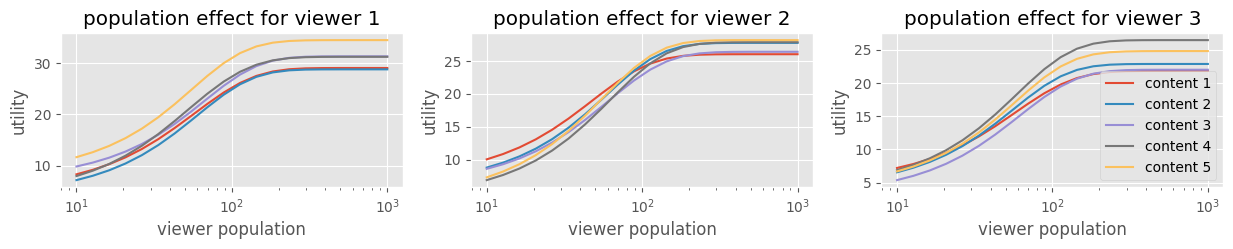

In [37]:
visualization_of_population_effect(
    setting="concave",
)

In [38]:
# long-short tradeoff
betas = torch.linspace(0.0, 1.0, 6)
long_short_logs = main(betas, setting="concave", policy_type="long_short_tradeoff", n_steps=200)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<ipython-input-20-001f76b06a8c>:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  policy_logit = torch.tensor(torch.log(initial_policy + 1e-4), requires_grad=True)
<ipython-input-20-001f76b06a8c>:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  policy_logit = torch.tensor(torch.log(initial_policy + 1e-4), requires_grad=True)


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

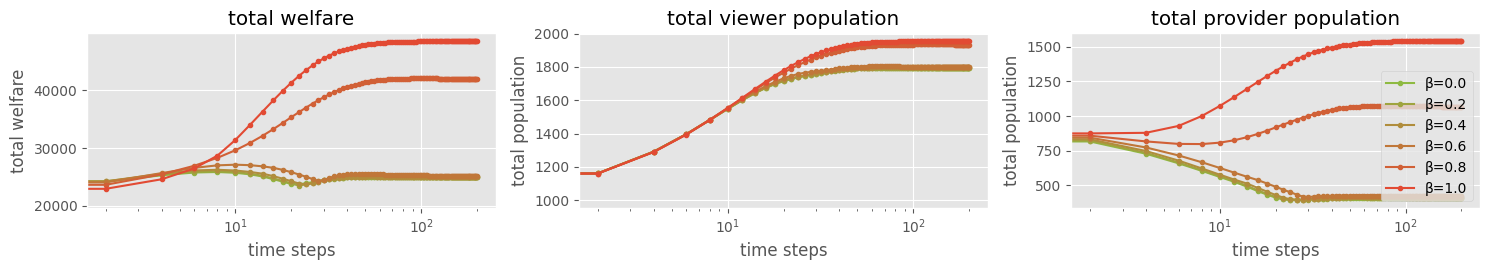

In [39]:
visualization_of_dynamics_with_varying_params(
    logs=long_short_logs,
    setting="concave",
    policy_type="long_short_tradeoff",
    params=betas,
    log_interval=2,
    use_log_scale_for_xaxis=True,
)

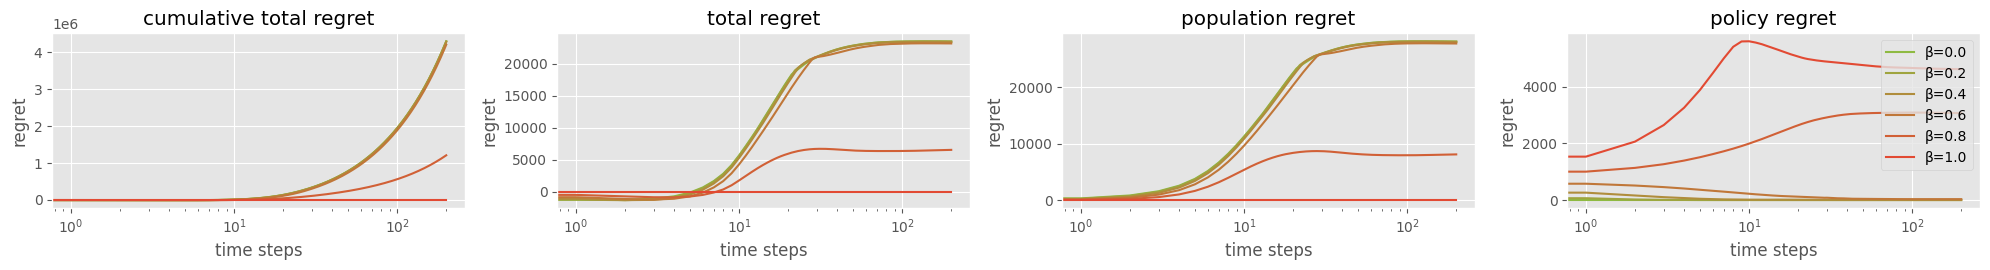

In [40]:
visualization_of_regret_with_varying_params(
    logs=long_short_logs,
    best_param_id=5,
    long_term_param_id=5,
    setting="concave",
    policy_type="long_short_tradeoff",
    params=betas,
    use_log_scale_for_xaxis=True,
)

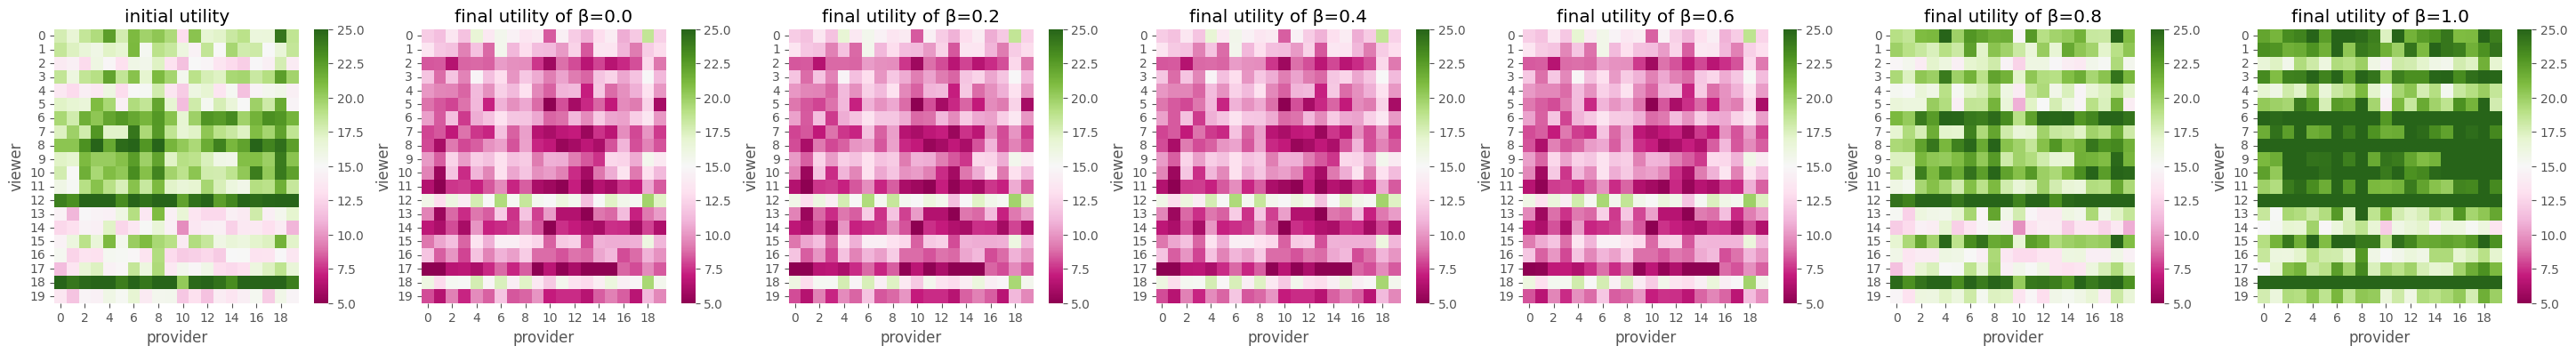

In [41]:
visualization_of_utility_matrix_with_varying_params(
    logs=long_short_logs,
    setting="concave",
    policy_type="long_short_tradeoff",
    params=betas,
)

In [42]:
# epsilon-greedy
epsilons = torch.linspace(0.0, 1.0, 6)
epsilon_greedy_logs = main(epsilons, setting="concave", policy_type="epsilon_greedy", n_steps=200)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

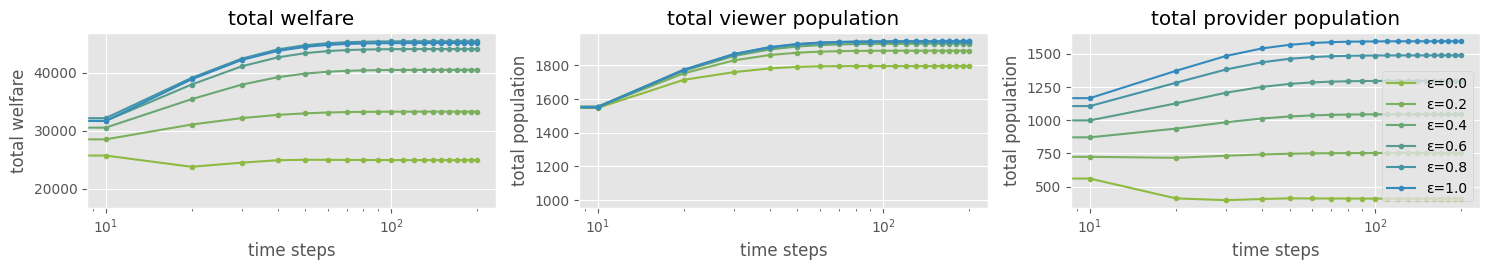

In [43]:
visualization_of_dynamics_with_varying_params(
    logs=epsilon_greedy_logs,
    setting="concave",
    policy_type="epsilon_greedy",
    params=epsilons,
    log_interval=10,
    use_log_scale_for_xaxis=True,
)

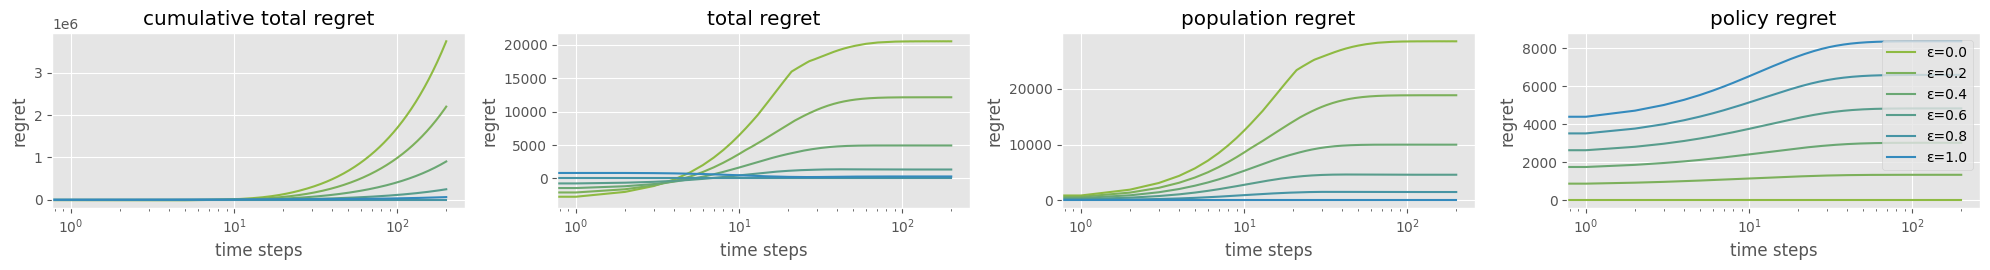

In [44]:
visualization_of_regret_with_varying_params(
    logs=epsilon_greedy_logs,
    best_param_id=4,
    long_term_param_id=5,
    setting="concave",
    policy_type="epsilon_greedy",
    params=epsilons,
    use_log_scale_for_xaxis=True,
)

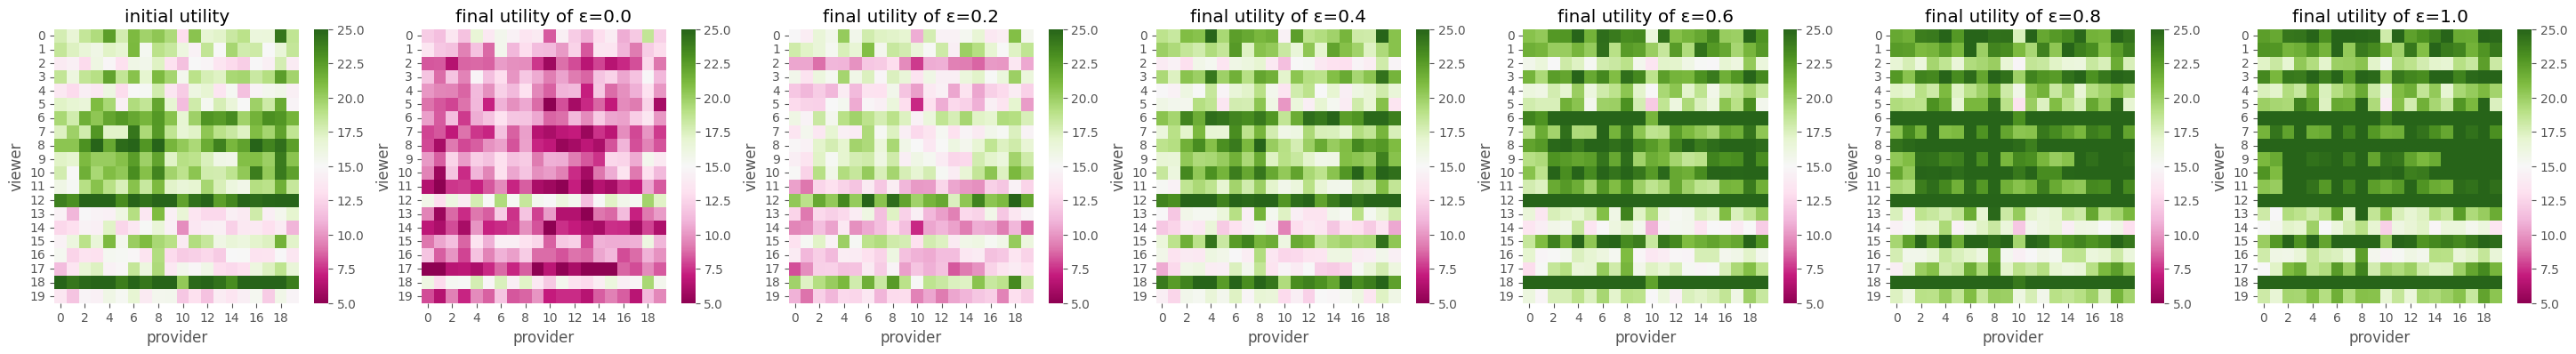

In [45]:
visualization_of_utility_matrix_with_varying_params(
    logs=epsilon_greedy_logs,
    setting="concave",
    policy_type="epsilon_greedy",
    params=epsilons,
)

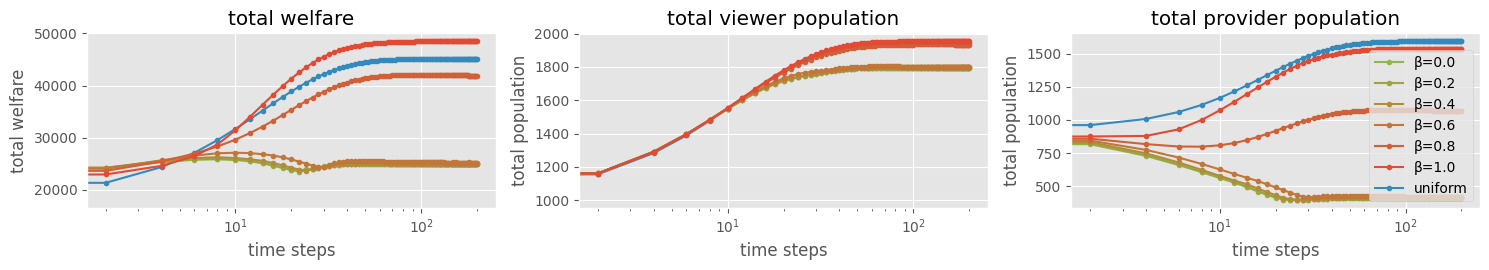

In [46]:

visualization_of_dynamics_main_text(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    setting="concave",
    params=betas,
    log_interval=2,
    use_log_scale_for_xaxis=True,
)

In [49]:
best_long_short_param_id = 5
best_epsilon_greedy_param_id = 5

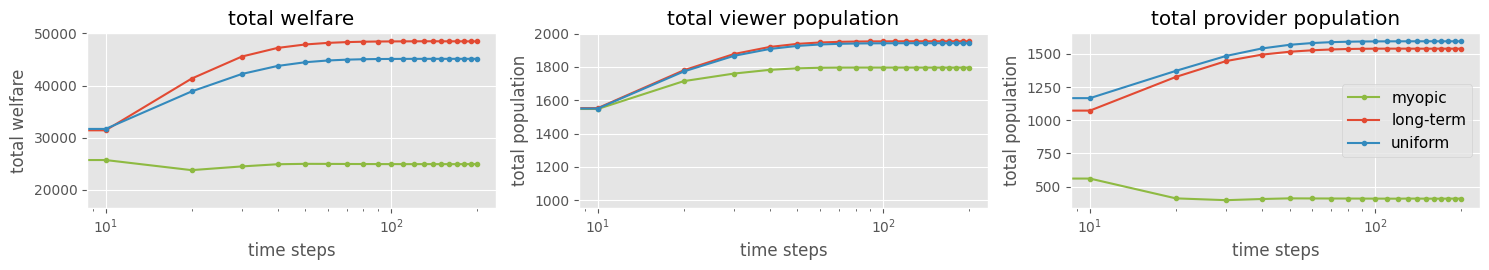

In [50]:
visualization_of_dynamics_with_representative_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
    setting="concave",
    log_interval=10,
    use_log_scale_for_xaxis=True,
)

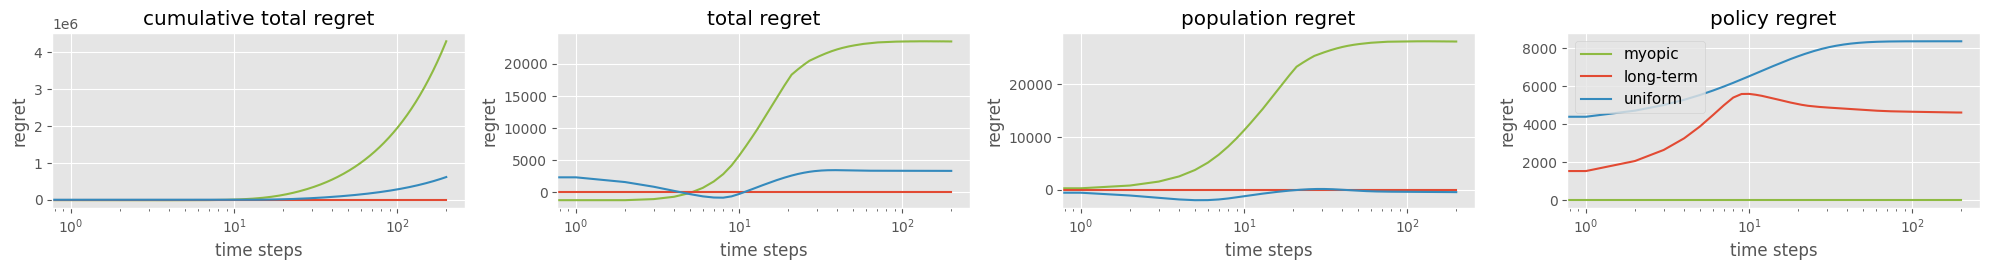

In [51]:
visualization_of_regret_with_representative_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
    setting="concave",
    use_log_scale_for_xaxis=True,
)

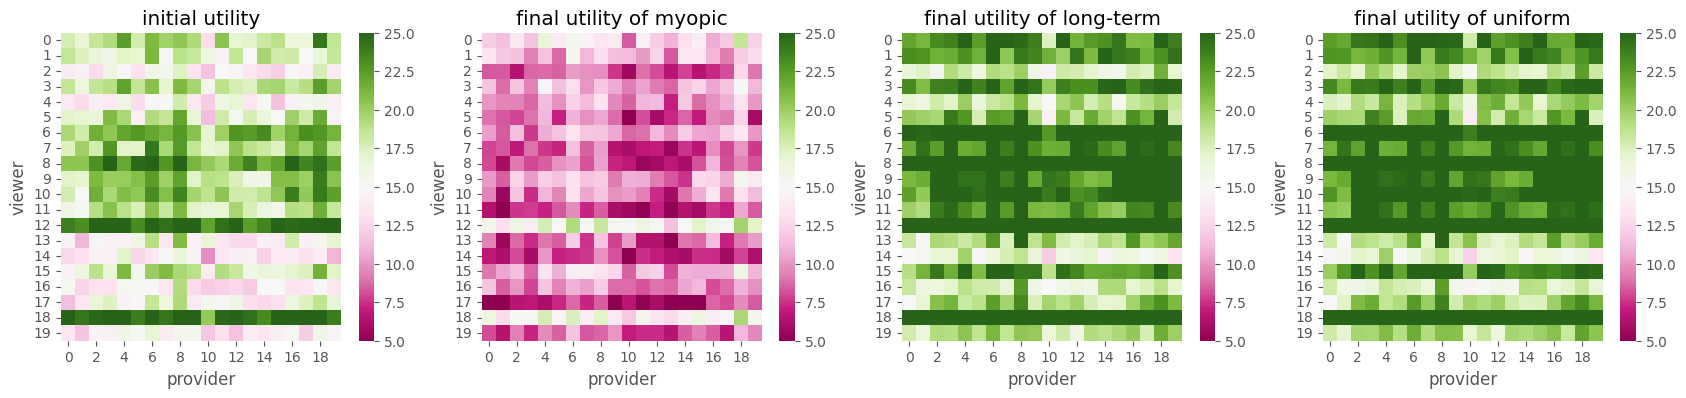

In [52]:
visualization_of_utility_matrix_with_representitive_methods(
    long_short_logs=long_short_logs,
    epsilon_greedy_logs=epsilon_greedy_logs,
    best_long_short_param_id=best_long_short_param_id,
    best_epsilon_greedy_param_id=best_epsilon_greedy_param_id,
    setting="concave",
)